In [128]:
import os, re, json, math, time, warnings, hashlib
from pathlib import Path
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
import seaborn as sns
import requests
import shap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import PredictionErrorDisplay
from sklearn.model_selection import LearningCurveDisplay, LearningCurveDisplay
from collections import Counter
from itertools import combinations
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, PredictionErrorDisplay
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
from sklearn.utils.discovery import all_displays

warnings.filterwarnings("ignore")

In [129]:
# =========================
# 数据统计
# =========================

df = pd.read_json("lianjia_houses.json", orient="records")
df

,name,type,status,avg_price,min_total_price,max_total_price,district,neighborhood,detailed_address,room,min_area,max_area,tag,url
0,青岛莱阳路8号,商业类,在售,75000,,,市南,文登路,莱阳路8号乙,,72,152,"海景,近地铁,公交直达,自持商业",https://qd.fang.lianjia.com/loupan/shinan/
1,青岛莱阳路8号,别墅,在售,120000,3600,10000,市南,文登路,莱阳路8号乙,"4室,6室",300,960,"海景,近地铁,公交直达,综合商场",https://qd.fang.lianjia.com/loupan/shinan/
2,青岛莱阳路8号,住宅,在售,110000,600,5600,市南,文登路,莱阳路8号乙,"1室,4室",83,466,"海景,近地铁,公交直达,综合商场",https://qd.fang.lianjia.com/loupan/shinan/
3,国信海天公馆,住宅,在售,100000,1200,3850,市南,五四广场,香港西路48号,"2室,4室",150,354,"近地铁,公交直达,医疗配套,综合商场",https://qd.fang.lianjia.com/loupan/shinan/
4,乾豪国际广场,写字楼,待售,,,,市南,闽江路,香港中路31号,,,,"近地铁,公交直达,医疗配套,超市",https://qd.fang.lianjia.com/loupan/shinan/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,阜丰观澜郡,住宅,售罄,,,,莱西,莱西,莱西市辽宁路18号,,,,"公交直达,公园,大型社区,超市",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...
831,岸芷汀兰,住宅,售罄,6000,70,70,莱西,莱西,烟台路岸芷汀兰东门口南侧,"0室,2室,3室",90,130,"公交直达,医疗配套,综合商场,公园",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...
832,梦想望城,住宅,售罄,5500,44,44,莱西,莱西,莱西-莱西,3室,93,120,"近主干道,公交直达,自持商业,公园",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...
833,品烁华年(莱西),住宅,售罄,7000,70,70,莱西,莱西,姜山新城海星南路26号（海星路与泰光路交汇处）,"2室,3室",89,125,"近主干道,成熟商圈,低密居所,视频看房",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...


In [130]:
# =========================
# 数据预处理
# =========================

# 去除空格
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# 替换空数据为 NaN
df.replace("", np.nan, inplace=True)

# 删除重复行
df.drop_duplicates(subset=['name'], inplace=True)

# 删除含缺失值行
df.dropna(subset=numeric_cols + ['room'], inplace=True)
df.reset_index(drop=True, inplace=True)

# 将数字字段转换为数值类型
numeric_cols = ['avg_price', 'min_total_price', 'max_total_price', 'min_area', 'max_area']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 字段规整
df['district'] = df['district'].str.replace(r'(区|市|县)$', '', regex=True)
df['type'] = df['type'].str.replace('类', '', regex=False)
df['neighborhood'] = df['neighborhood'].fillna(df['district'])
df['room_list'] = df['room'].str.split(',').apply(lambda lst: [r.strip() for r in lst if r.strip()])
df['tag_list'] = df['tag'].str.split(',').apply(lambda lst: [t.strip() for t in lst if t.strip()])
df

,name,type,status,avg_price,min_total_price,max_total_price,district,neighborhood,detailed_address,room,min_area,max_area,tag,url,room_list,tag_list
0,国信海天公馆,住宅,在售,100000,1200.0,3850.0,市南,五四广场,香港西路48号,"2室,4室",150,354,"近地铁,公交直达,医疗配套,综合商场",https://qd.fang.lianjia.com/loupan/shinan/,"[2室, 4室]","[近地铁, 公交直达, 医疗配套, 综合商场]"
1,青铁鼎峰·云上观澜,住宅,在售,34000,320.0,857.0,市南,团岛,团岛三路10号,"3室,4室",110,204,"近地铁,公交直达,公园,现房",https://qd.fang.lianjia.com/loupan/shinan/,"[3室, 4室]","[近地铁, 公交直达, 公园, 现房]"
2,保利青铁天珺瑞海地,住宅,在售,30000,370.0,620.0,市南,西镇,四川路保利青铁天珺瑞海地,"3室,4室",127,183,"近地铁,公交直达,期房,近期开盘",https://qd.fang.lianjia.com/loupan/shinan/pg2/,"[3室, 4室]","[近地铁, 公交直达, 期房, 近期开盘]"
3,大都汇盛元,住宅,在售,17000,152.5,232.5,市北,水清沟,德安路59号,"2室,3室",81,122,"近地铁,公交直达,公园,现房",https://qd.fang.lianjia.com/loupan/shibei/#shibei,"[2室, 3室]","[近地铁, 公交直达, 公园, 现房]"
4,明翠雅居,住宅,在售,29000,490.0,490.0,市北,浮山后,富源一路88号,3室,72,160,"山景,近主干道,公交直达,医疗配套",https://qd.fang.lianjia.com/loupan/shibei/#shibei,[3室],"[山景, 近主干道, 公交直达, 医疗配套]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,中梁首府,住宅,售罄,7000,73.0,73.0,莱西,莱西,莱西市青岛路47#,3室,104,119,"近主干道,公交直达,综合商场,公园",https://qd.fang.lianjia.com/loupan/laixi/#laixi,[3室],"[近主干道, 公交直达, 综合商场, 公园]"
389,河畔嘉园,住宅,售罄,6000,92.0,92.0,莱西,莱西,莱西-莱西,"2室,3室,4室",96,153,"公交直达,低密居所,小高层,超市",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...,"[2室, 3室, 4室]","[公交直达, 低密居所, 小高层, 超市]"
390,岸芷汀兰,住宅,售罄,6000,70.0,70.0,莱西,莱西,烟台路岸芷汀兰东门口南侧,"0室,2室,3室",90,130,"公交直达,医疗配套,综合商场,公园",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...,"[0室, 2室, 3室]","[公交直达, 医疗配套, 综合商场, 公园]"
391,品烁华年(莱西),住宅,售罄,7000,70.0,70.0,莱西,莱西,姜山新城海星南路26号（海星路与泰光路交汇处）,"2室,3室",89,125,"近主干道,成熟商圈,低密居所,视频看房",https://qd.fang.lianjia.com/loupan/laixi/pg5/#...,"[2室, 3室]","[近主干道, 成熟商圈, 低密居所, 视频看房]"


In [131]:
# ------------------------------------------------------------
# 数据可视化
# ------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'SimHei',
    'font.size': 20,
    'axes.titlesize': 26,
    'axes.titleweight': 'bold',
    'axes.labelsize': 22,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.title_fontsize': 16,
    'legend.fontsize': 20,
    'axes.titlepad': 15,
    'axes.labelpad': 10,
    'figure.autolayout': True,
    'axes.unicode_minus': False
})
sns.set_theme(style="whitegrid", font='SimHei', font_scale=1.6)


def hr(title: str):
    print("\n" + "=" * 34)
    print(f"{title}".strip())
    print("=" * 34)


def subhr(title: str):
    print("\n" + "-" * 34)
    print(title)
    print("-" * 34)


def add_bar_labels(ax, decimals=0, fontsize=16, color='black', weight='bold', padding=2):
    fmt = f".{decimals}f"
    for container in ax.containers:
        rect = container[0]
        is_horizontal = rect.get_width() > rect.get_height()

        labels = [
            f"{(v.get_width() if is_horizontal else v.get_height()):{fmt}}" if
            (v.get_width() if is_horizontal else v.get_height()) > 0 else ''
            for v in container
        ]

        ax.bar_label(container, labels=labels, label_type='edge', padding=padding, fontsize=fontsize, weight=weight,
                     color=color, clip_on=False)

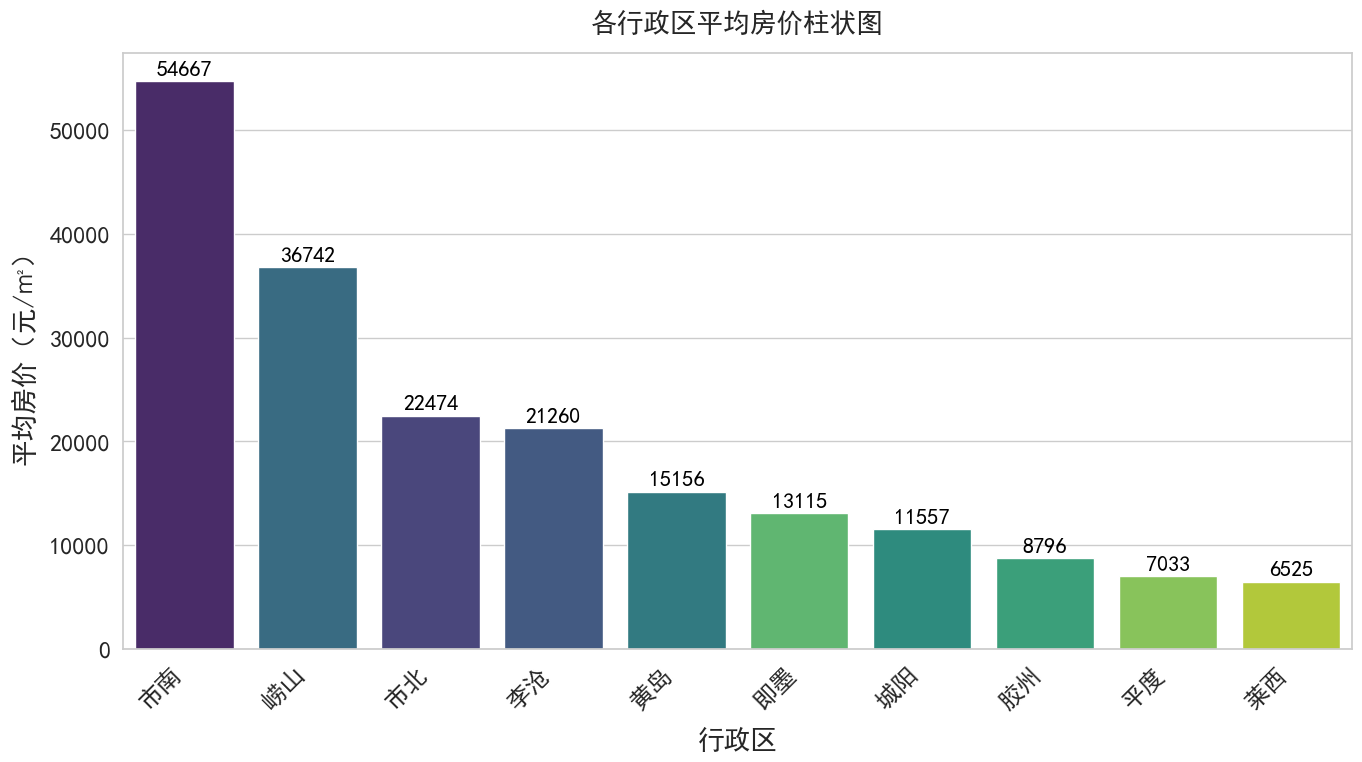

In [132]:
# ========== 各行政区平均房价柱状图 ==========
plt.figure(figsize=(14, 8))
order = df.groupby('district')['avg_price'].mean().sort_values(ascending=False).index
ax = sns.barplot(x='district', y='avg_price', data=df, estimator=np.mean, errorbar=None, palette='viridis',
                 hue='district', order=order)
add_bar_labels(ax)
plt.title("各行政区平均房价柱状图")
plt.xticks(rotation=45, ha='right')
plt.xlabel("行政区")
plt.ylabel("平均房价（元/㎡）")
plt.tight_layout()
plt.show()

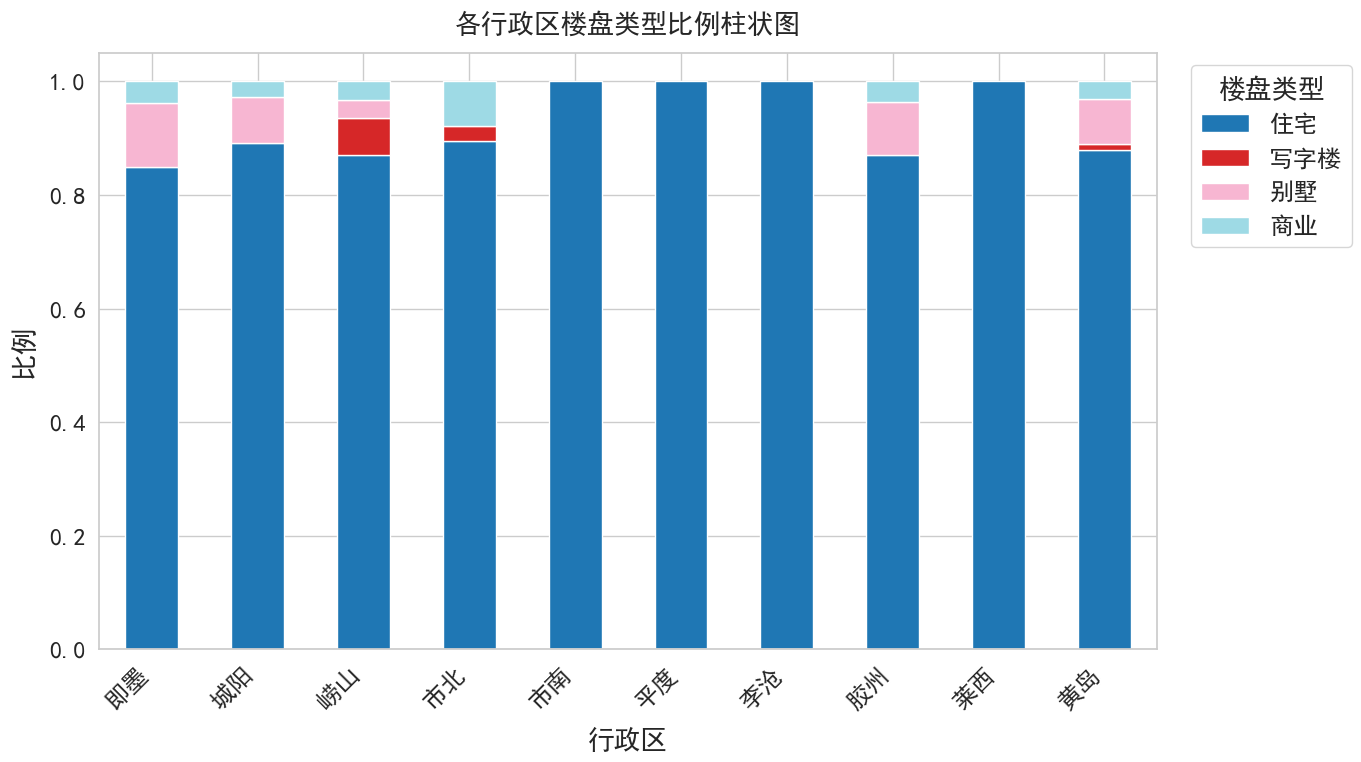

In [133]:
# ========== 各行政区楼盘类型比例柱状图 ==========
building_distr = df.groupby(['district', 'type']).size().reset_index(name='count')
total = building_distr.groupby('district')['count'].sum().reset_index(name='total')
building_distr = building_distr.merge(total, on='district')
building_distr['percent'] = building_distr['count'] / building_distr['total']

pivot = building_distr.pivot(index='district', columns='type', values='percent').fillna(0)
pivot.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

plt.title('各行政区楼盘类型比例柱状图')
plt.xticks(rotation=45, ha='right')
plt.xlabel('行政区')
plt.ylabel('比例')
plt.legend(title='楼盘类型', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

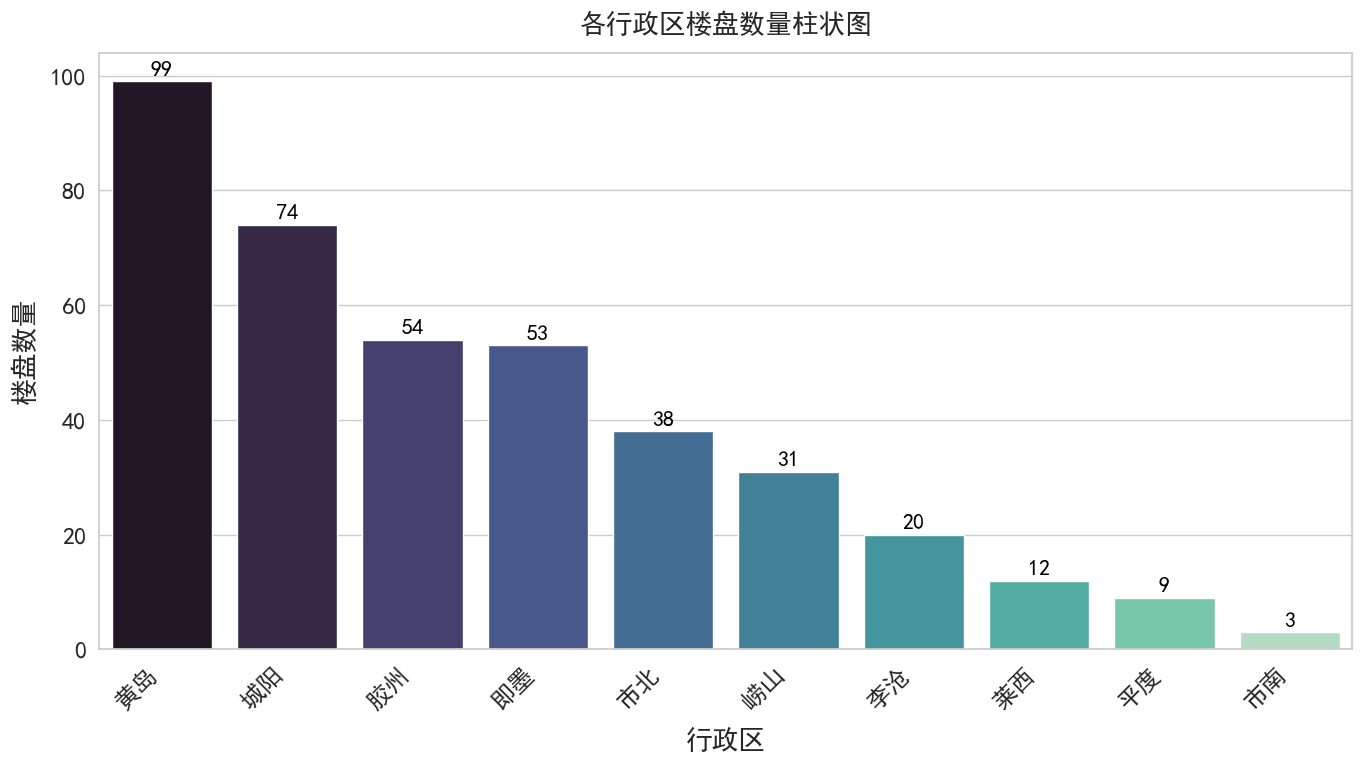

In [134]:
# ========== 各行政区楼盘数量柱状图 ==========
plt.figure(figsize=(14, 8))
order = df['district'].value_counts().sort_values(ascending=False).index
district_counts = df['district'].value_counts().reset_index()
ax = sns.barplot(x='district', y='count', data=district_counts, order=order, palette='mako', hue='district',
                 legend=False, errorbar=None)
add_bar_labels(ax)
plt.title("各行政区楼盘数量柱状图")
plt.xticks(rotation=45, ha='right')
plt.xlabel("行政区")
plt.ylabel("楼盘数量")
plt.tight_layout()
plt.show()

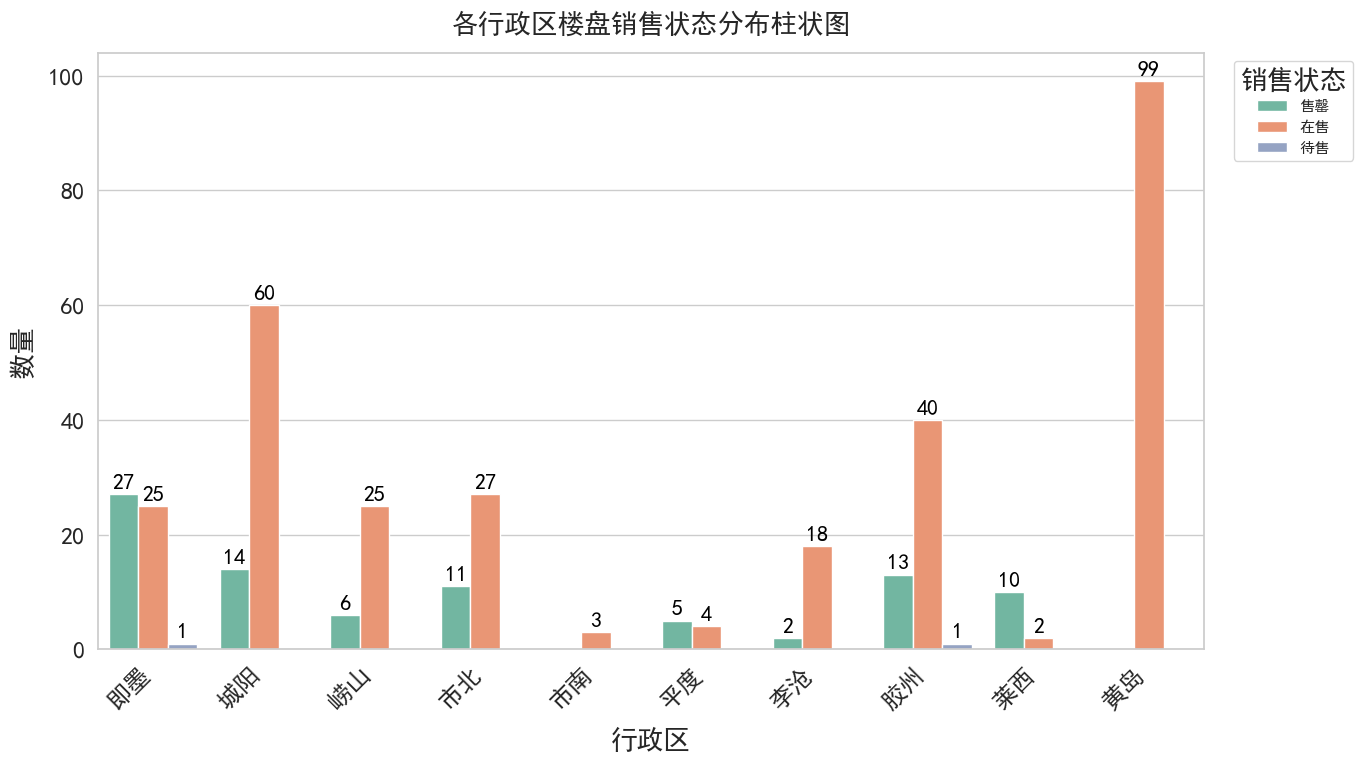

In [135]:
# ========== 各行政区楼盘销售状态分布柱状图 ==========
status_dist = df.groupby(['district', 'status']).size().reset_index(name='count')
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=status_dist, x='district', y='count', hue='status', palette='Set2')
add_bar_labels(ax)
plt.title('各行政区楼盘销售状态分布柱状图')
plt.xticks(rotation=45, ha='right')
plt.xlabel('行政区')
plt.ylabel('数量')
plt.legend(title='销售状态', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

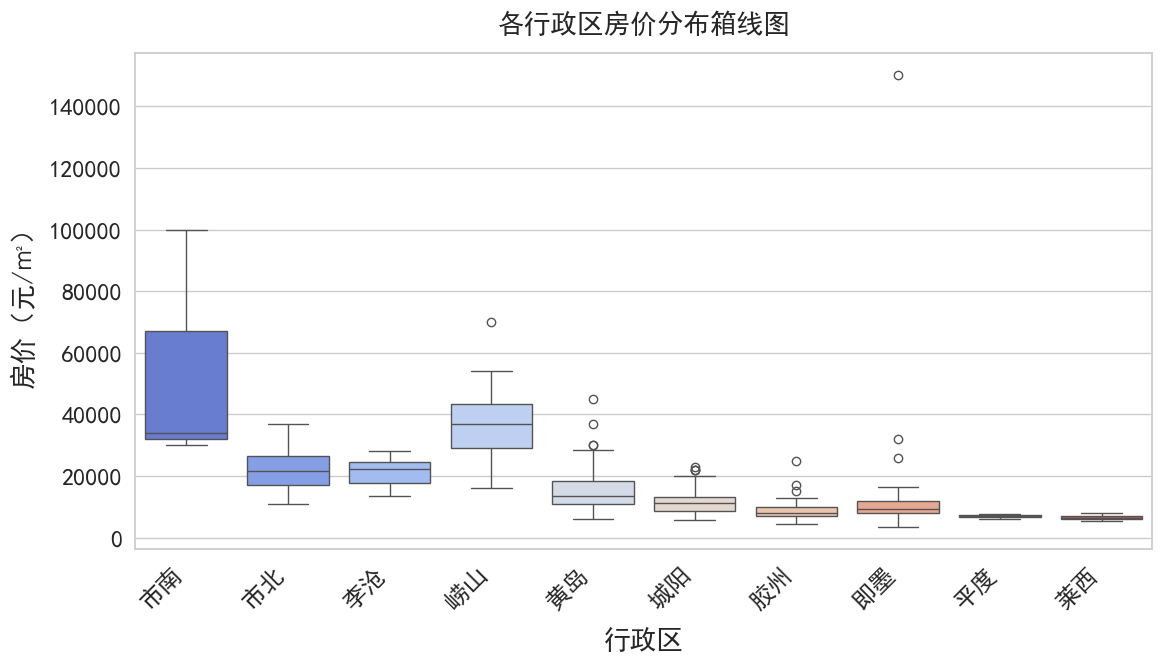

In [136]:
# ========== 各行政区房价分布箱线图 ==========
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='district', y='avg_price', palette='coolwarm', hue='district')
plt.title('各行政区房价分布箱线图')
plt.xticks(rotation=45, ha='right')
plt.xlabel('行政区')
plt.ylabel('房价（元/㎡）')
plt.tight_layout()
plt.show()

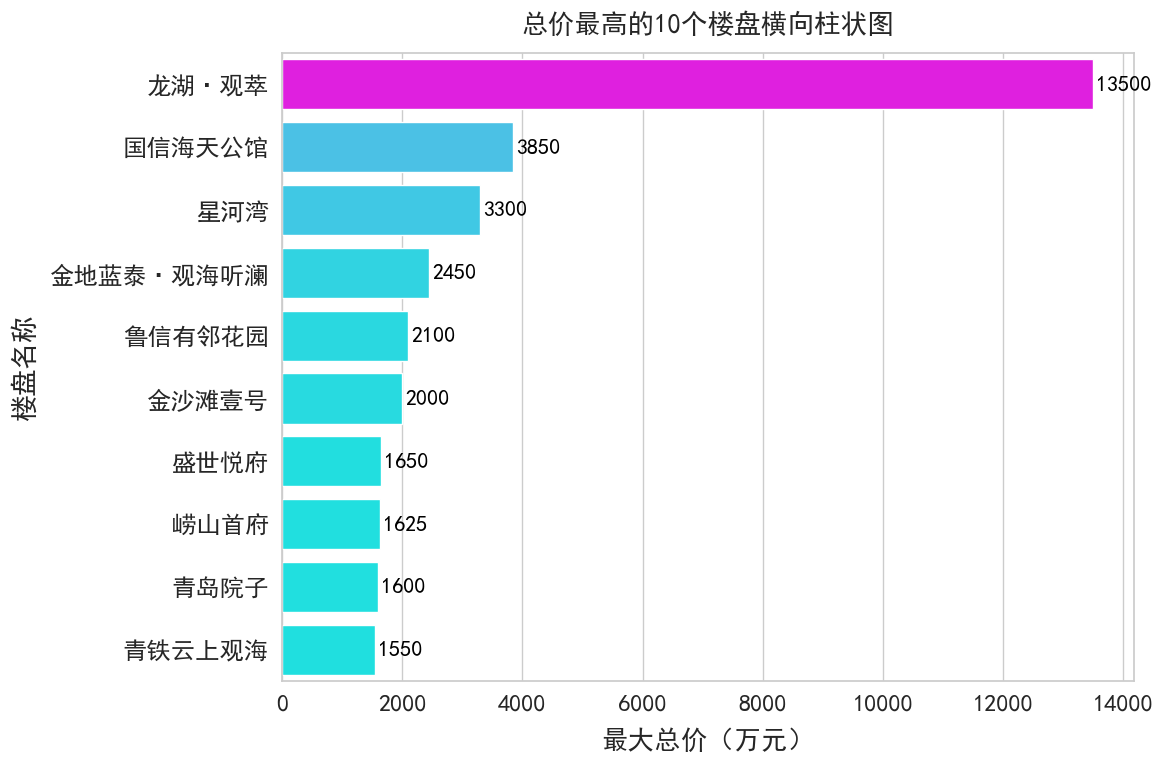

In [137]:
# ========== 总价最高的10个楼盘横向柱状图 ==========
plt.figure(figsize=(12, 8))
top10 = df.nlargest(10, 'max_total_price')
ax = sns.barplot(x='max_total_price', y='name', data=top10, palette='cool', hue='max_total_price')
plt.legend([], [], frameon=False)
add_bar_labels(ax)
plt.title("总价最高的10个楼盘横向柱状图")
plt.xlabel("最大总价（万元）")
plt.ylabel("楼盘名称")
plt.tight_layout()
plt.show()

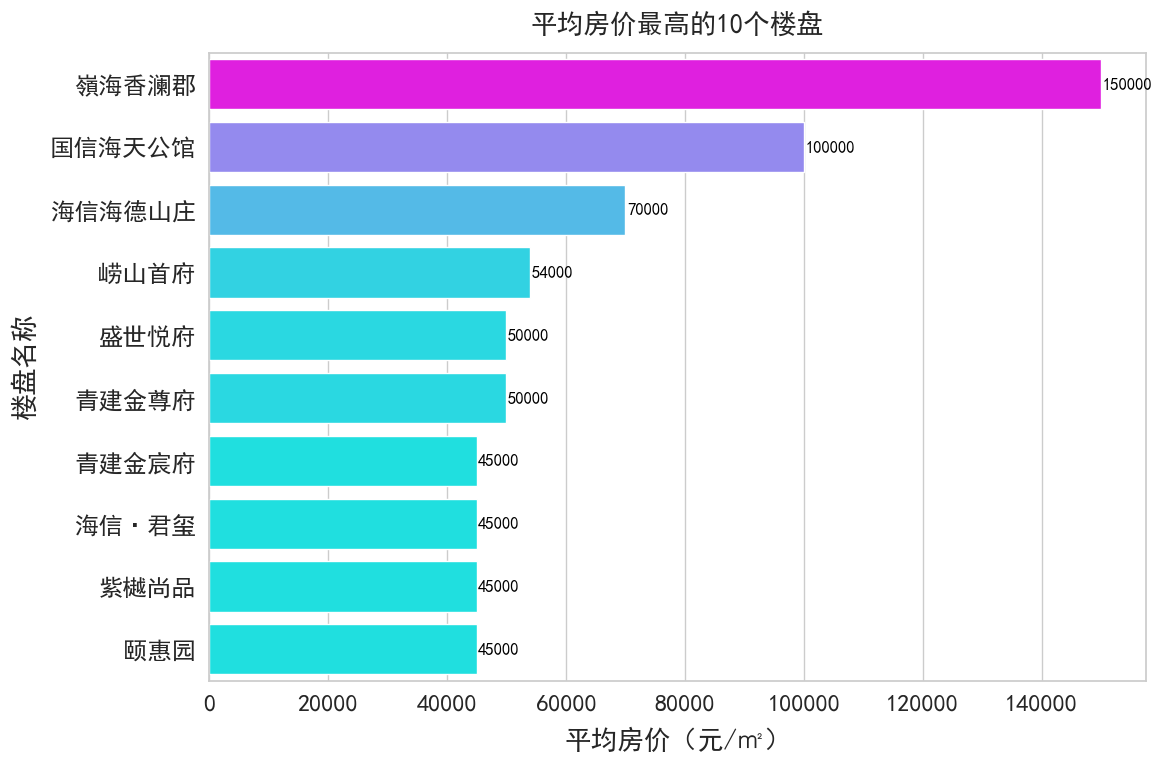

In [138]:
# ========== 平均房价最高的10个楼盘（横向柱状图） ==========
plt.figure(figsize=(12, 8))
top10_avg = df.nlargest(10, 'avg_price')
ax = sns.barplot(x='avg_price', y='name', data=top10_avg, palette='cool', hue='avg_price', dodge=False)
plt.legend([], [], frameon=False)
# 添加数值标签（在每个柱子的右侧）
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',  # 整数格式（不显示小数）
        label_type='edge',  # 标签显示在边缘
        padding=1,  # 离柱子距离
        fontsize=12,
        weight='bold',
        color='black'  # 如果背景深可改为黑
    )
plt.title("平均房价最高的10个楼盘")
plt.xlabel("平均房价（元/㎡）")
plt.ylabel("楼盘名称")
plt.tight_layout()
plt.show()

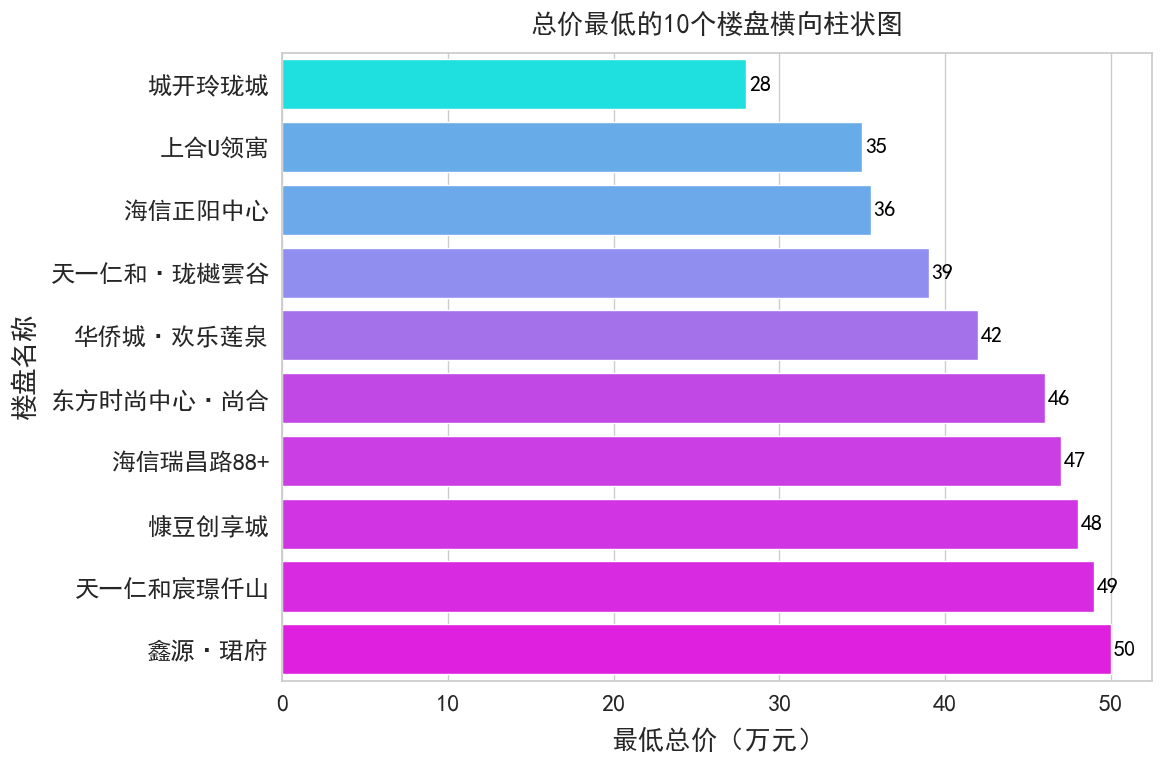

In [139]:
# ========== 总价最低的10个楼盘横向柱状图 ==========
plt.figure(figsize=(12, 8))
last10 = df.nsmallest(10, 'min_total_price')
ax = sns.barplot(x='min_total_price', y='name', data=last10, palette='cool', hue='min_total_price')
plt.legend([], [], frameon=False)
add_bar_labels(ax)
plt.title("总价最低的10个楼盘横向柱状图")
plt.xlabel("最低总价（万元）")
plt.ylabel("楼盘名称")
plt.tight_layout()
plt.show()

In [140]:
# =========================
# 标签与房价关系分析
# =========================
hr("标签与房价关系分析")

# 特征选择
df_tag = df[['tag_list', 'avg_price']].copy()

# 分析高价和低价标签
median_price = df_tag['avg_price'].median()
df_tag['price_level'] = np.where(df_tag['avg_price'] >= median_price, '高价', '低价')

tag_high_ratio = (
    df_tag.explode('tag_list')
    .groupby('tag_list')['price_level']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .sort_values('高价', ascending=False)
)

high_tags = tag_high_ratio['高价'].head(5)
low_tags = tag_high_ratio['低价'].tail(5).iloc[::-1]

subhr("更容易出现在高价楼盘中的标签（Top 5）：")
for tag, val in high_tags.items():
    print(f"标签【{tag}】 → 高价占比 {val:.2%}")

subhr("更容易出现在低价楼盘中的标签（Top 5）：")
for tag, val in low_tags.items():
    print(f"标签【{tag}】 → 低价占比 {val:.2%}")

high_list = [t for t, v in high_tags.items()]
low_list = [t for t, v in low_tags.items()]

subhr("结论如下：")
if high_list:
    print(f"带有 {'、'.join(high_list[:5])} 等标签的楼盘，普遍房价较高。")
if low_list:
    print(f"带有 {'、'.join(low_list[:5])} 等标签的楼盘，普遍房价较低。")


标签与房价关系分析

----------------------------------
更容易出现在高价楼盘中的标签（Top 5）：
----------------------------------
标签【一梯一户】 → 高价占比 100.00%
标签【叠加别墅】 → 高价占比 100.00%
标签【休闲会所】 → 高价占比 100.00%
标签【私属庭院】 → 高价占比 100.00%
标签【近期开盘】 → 高价占比 100.00%

----------------------------------
更容易出现在低价楼盘中的标签（Top 5）：
----------------------------------
标签【车位充足】 → 低价占比 100.00%
标签【联排别墅】 → 低价占比 100.00%
标签【科技住宅】 → 低价占比 100.00%
标签【已交房2年内】 → 低价占比 100.00%
标签【小户型】 → 低价占比 100.00%

----------------------------------
结论如下：
----------------------------------
带有 一梯一户、叠加别墅、休闲会所、私属庭院、近期开盘 等标签的楼盘，普遍房价较高。
带有 车位充足、联排别墅、科技住宅、已交房2年内、小户型 等标签的楼盘，普遍房价较低。



标签的模式挖掘（Apriori）

----------------------------------
标签的关联规则（Top 8）：
----------------------------------
当楼盘标签包含【综合商场, 期房】时，大概率也包含【公交直达】（置信度=0.95, 提升度=1.18）
当楼盘标签包含【期房】时，大概率也包含【公交直达】（置信度=0.94, 提升度=1.16）
当楼盘标签包含【公园, 医疗配套】时，大概率也包含【公交直达】（置信度=0.93, 提升度=1.15）
当楼盘标签包含【综合商场, 现房】时，大概率也包含【公交直达】（置信度=0.92, 提升度=1.14）
当楼盘标签包含【综合商场, 公园】时，大概率也包含【公交直达】（置信度=0.91, 提升度=1.13）
当楼盘标签包含【医疗配套】时，大概率也包含【公交直达】（置信度=0.90, 提升度=1.11）
当楼盘标签包含【现房】时，大概率也包含【公交直达】（置信度=0.90, 提升度=1.11）
当楼盘标签包含【低密居所】时，大概率也包含【公交直达】（置信度=0.89, 提升度=1.10）

----------------------------------
通过Apriori算法挖掘出标签的几个关联规则：
----------------------------------
· 当楼盘标签包含【综合商场, 期房】时，大概率也包含【公交直达】
· 当楼盘标签包含【期房】时，大概率也包含【公交直达】
· 当楼盘标签包含【公园, 医疗配套】时，大概率也包含【公交直达】
· 当楼盘标签包含【综合商场, 现房】时，大概率也包含【公交直达】
· 当楼盘标签包含【综合商场, 公园】时，大概率也包含【公交直达】


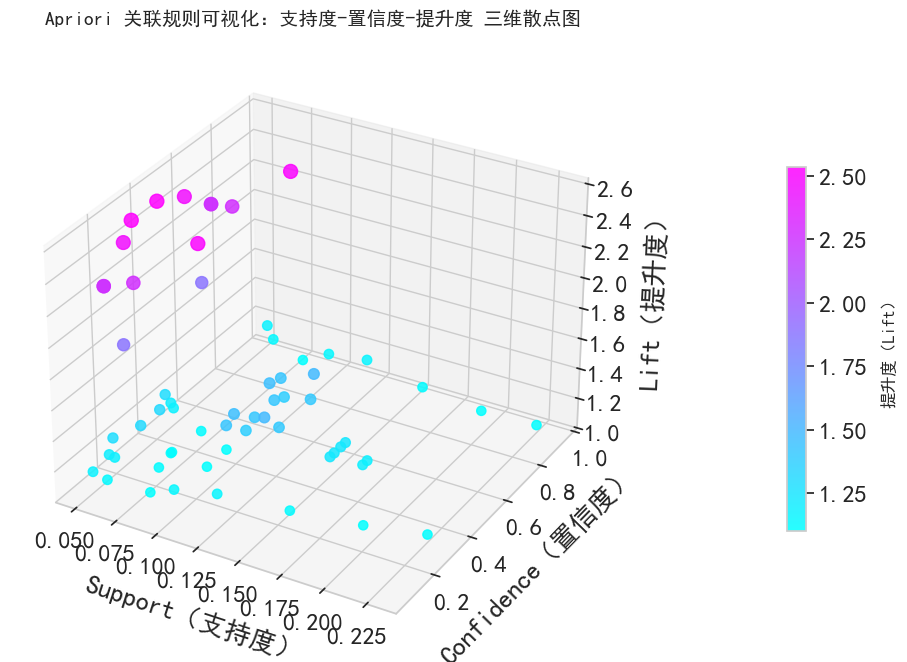

In [141]:
# =========================
# 标签的模式挖掘（Apriori）
# =========================
hr("标签的模式挖掘（Apriori）")

transactions = df_tag['tag_list'].tolist()
all_tags = sorted({t for tx in transactions for t in tx})
df_txn = pd.DataFrame([[t in tx for t in all_tags] for tx in transactions], columns=all_tags).astype(bool)

freq = apriori(df_txn, min_support=0.05, use_colnames=True)
rules = association_rules(freq, metric="lift", min_threshold=1.1).sort_values("confidence", ascending=False)

subhr("标签的关联规则（Top 8）：")
patterns = []
for _, row in rules.head(8).iterrows():
    a = ', '.join(list(row['antecedents']))
    c = ', '.join(list(row['consequents']))
    conf, lift = row['confidence'], row['lift']
    sentence = f"当楼盘标签包含【{a}】时，大概率也包含【{c}】（置信度={conf:.2f}, 提升度={lift:.2f}）"
    patterns.append(sentence)
    print(sentence)

subhr("通过Apriori算法挖掘出标签的几个关联规则：")
if len(patterns) > 0:
    for p in patterns[:5]:
        p = re.sub(r'（.*?）', '', p)
        print("· " + p)

support = rules['support']
confidence = rules['confidence']
lift = rules['lift']

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    support,
    confidence,
    lift,
    s=lift * 40,
    alpha=0.85,
    c=lift,
    cmap='cool'
)

ax.set_xlabel('Support（支持度）')
ax.set_ylabel('Confidence（置信度）')
ax.set_zlabel('Lift（提升度）')

cbar = plt.colorbar(sc, shrink=0.6, pad=0.15)
cbar.set_label("提升度（Lift）", fontsize=12)

plt.title("Apriori 关联规则可视化：支持度-置信度-提升度 三维散点图", fontsize=14)
plt.show()


分类：预测楼盘类型

----------------------------------
逻辑回归
----------------------------------
逻辑回归 —— 最优参数： model__C = 5, model__max_iter = 300, model__penalty = l2, model__solver = lbfgs
逻辑回归 —— 最优 Macro-F1（CV）： 0.489450930322538
逻辑回归 —— Acc 0.848 | Macro-F1 0.314 | W-F1 0.823
逻辑回归 —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.892     0.957     0.923        69
         写字楼      0.000     0.000     0.000         1
          别墅      0.000     0.000     0.000         5
          商业      0.500     0.250     0.333         4

    accuracy                          0.848        79
   macro avg      0.348     0.302     0.314        79
weighted avg      0.804     0.848     0.823        79



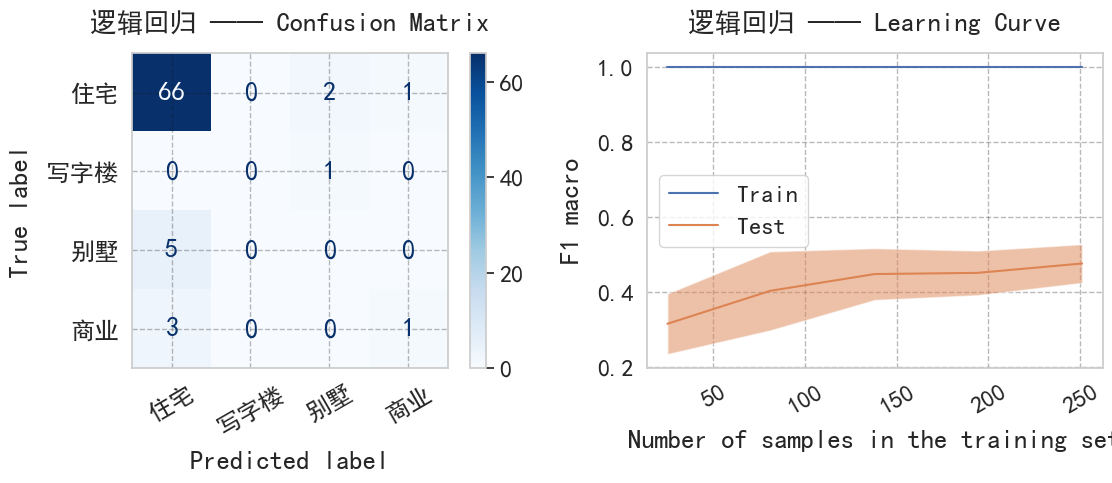


----------------------------------
SVM
----------------------------------
SVM —— 最优参数： model__C = 5, model__gamma = scale, model__kernel = rbf, model__probability = True
SVM —— 最优 Macro-F1（CV）： 0.49583137002927113
SVM —— Acc 0.886 | Macro-F1 0.308 | W-F1 0.844
SVM —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.896     1.000     0.945        69
         写字楼      0.000     0.000     0.000         1
          别墅      0.500     0.200     0.286         5
          商业      0.000     0.000     0.000         4

    accuracy                          0.886        79
   macro avg      0.349     0.300     0.308        79
weighted avg      0.814     0.886     0.844        79



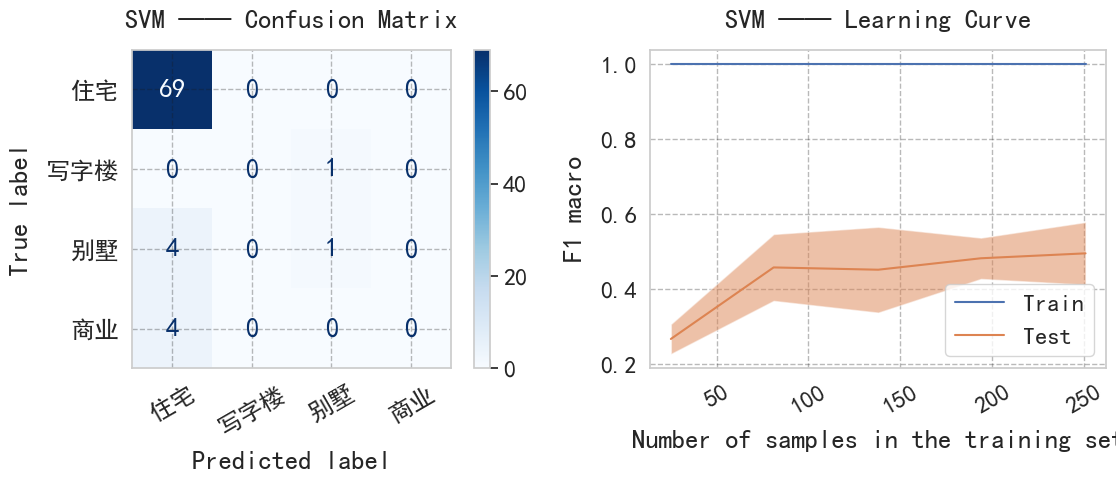


----------------------------------
KNN
----------------------------------
KNN —— 最优参数： model__n_neighbors = 3, model__p = 1, model__weights = distance
KNN —— 最优 Macro-F1（CV）： 0.4461463233630941
KNN —— Acc 0.873 | Macro-F1 0.233 | W-F1 0.814
KNN —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.873     1.000     0.932        69
         写字楼      0.000     0.000     0.000         1
          别墅      0.000     0.000     0.000         5
          商业      0.000     0.000     0.000         4

    accuracy                          0.873        79
   macro avg      0.218     0.250     0.233        79
weighted avg      0.763     0.873     0.814        79



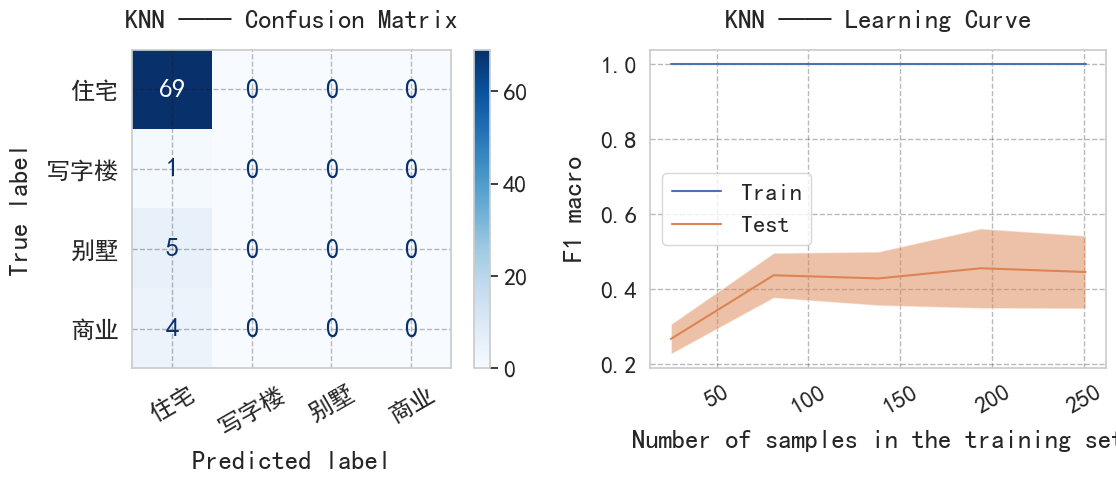


----------------------------------
决策树（CART）
----------------------------------
决策树（CART） —— 最优参数： model__criterion = gini, model__max_depth = 8, model__min_samples_leaf = 4
决策树（CART） —— 最优 Macro-F1（CV）： 0.5509290003090973
决策树（CART） —— Acc 0.911 | Macro-F1 0.550 | W-F1 0.900
决策树（CART） —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.931     0.971     0.950        69
         写字楼      0.000     0.000     0.000         1
          别墅      0.667     0.400     0.500         5
          商业      0.750     0.750     0.750         4

    accuracy                          0.911        79
   macro avg      0.587     0.530     0.550        79
weighted avg      0.893     0.911     0.900        79



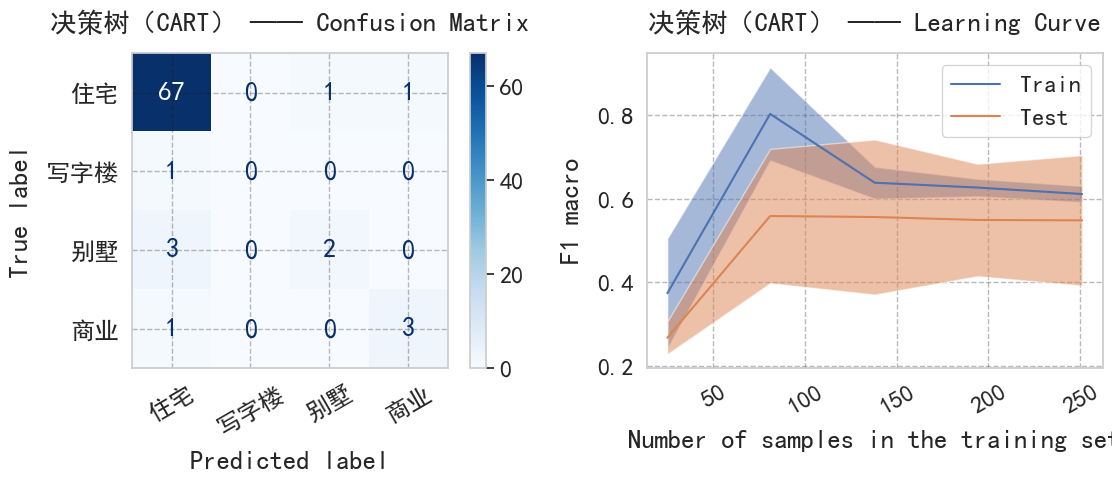


----------------------------------
集成学习（AdaBoost）
----------------------------------
集成学习（AdaBoost） —— 最优参数： model__learning_rate = 1.0, model__n_estimators = 50
集成学习（AdaBoost） —— 最优 Macro-F1（CV）： 0.5516858980045984
集成学习（AdaBoost） —— Acc 0.924 | Macro-F1 0.527 | W-F1 0.904
集成学习（AdaBoost） —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.932     1.000     0.965        69
         写字楼      0.000     0.000     0.000         1
          别墅      0.500     0.200     0.286         5
          商业      1.000     0.750     0.857         4

    accuracy                          0.924        79
   macro avg      0.608     0.487     0.527        79
weighted avg      0.897     0.924     0.904        79



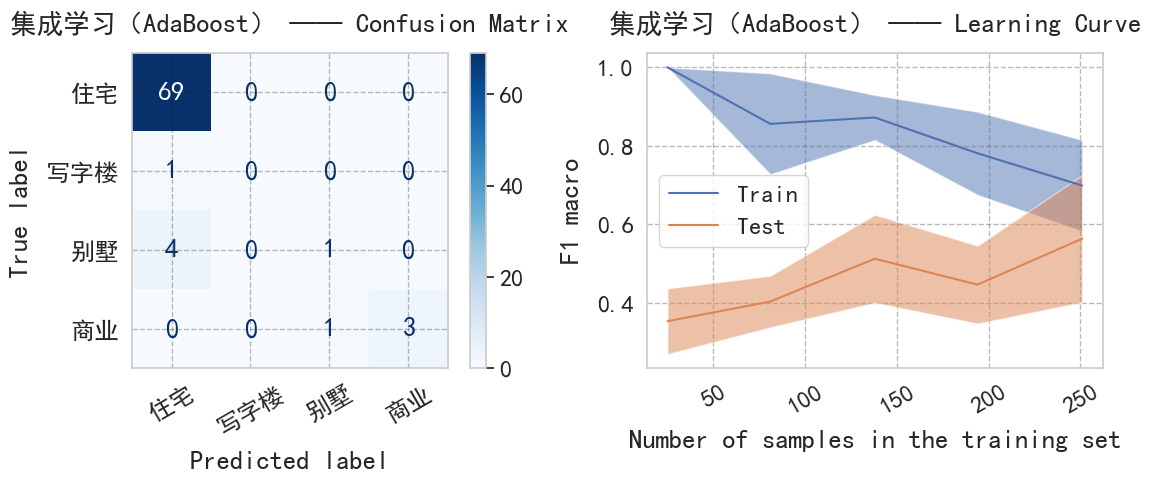


----------------------------------
集成学习（XGBoost）
----------------------------------
集成学习（XGBoost） —— 最优参数： model__learning_rate = 0.05, model__max_depth = 5, model__n_estimators = 100, model__subsample = 0.7
集成学习（XGBoost） —— 最优 Macro-F1（CV）： 0.5136260128081322
集成学习（XGBoost） —— Acc 0.924 | Macro-F1 0.537 | W-F1 0.902
集成学习（XGBoost） —— 分类报告：
              precision    recall  f1-score   support

          住宅      0.920     1.000     0.958        69
         写字楼      0.000     0.000     0.000         1
          别墅      1.000     0.200     0.333         5
          商业      1.000     0.750     0.857         4

    accuracy                          0.924        79
   macro avg      0.730     0.487     0.537        79
weighted avg      0.917     0.924     0.902        79



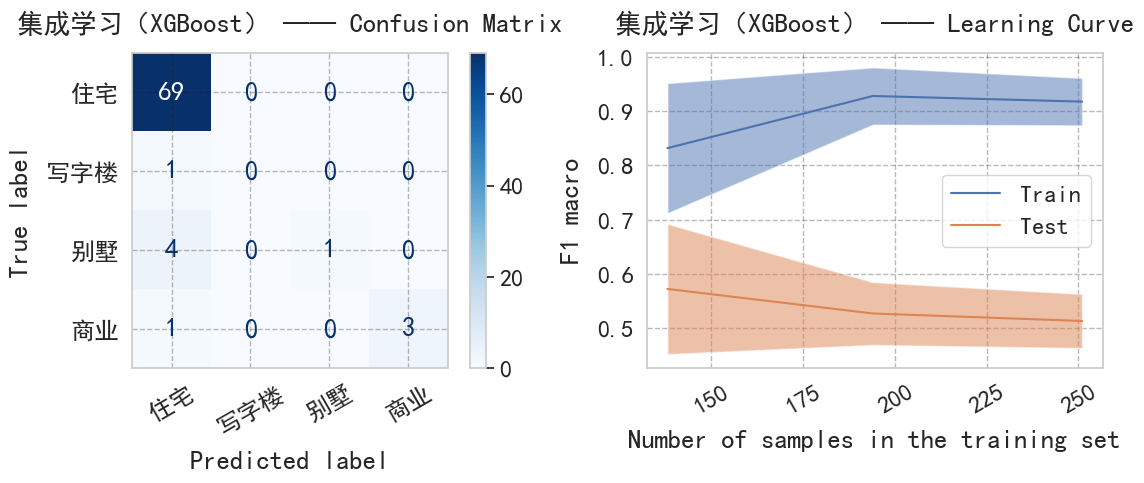


----------------------------------
模型性能对比表
----------------------------------
                accuracy  macro_f1  weighted_f1
逻辑回归            0.848101  0.314103     0.823109
SVM             0.886076  0.307730     0.843642
KNN             0.873418  0.233108     0.814403
决策树（CART）       0.911392  0.550089     0.899677
集成学习（AdaBoost）  0.924051  0.526973     0.904361
集成学习（XGBoost）   0.924051  0.537202     0.901522

----------------------------------
最优模型：决策树（CART）（Macro-F1 = 0.550）
----------------------------------


In [142]:
# =========================
# 分类：预测楼盘类型
# =========================
hr("分类：预测楼盘类型")

# 特征选择
X_cls = df[['min_area', 'max_area', 'avg_price', 'min_total_price', 'max_total_price',
            'status', 'district', 'neighborhood', 'tag_list', 'room_list']].copy()
label_enc = LabelEncoder()
y_cls = label_enc.fit_transform(df['type'])

# 将标签列和户型列拆分为独热编码
mlb = MultiLabelBinarizer()
tag_encoded = pd.DataFrame(mlb.fit_transform(X_cls['tag_list']),
                           columns=[f"tag_{t}" for t in mlb.classes_],
                           index=X_cls.index)
room_encoded = pd.DataFrame(mlb.fit_transform(X_cls['room_list']),
                            columns=[f"room_{r}" for r in mlb.classes_],
                            index=X_cls.index)
# 合并标签列和户型列
X_cls = pd.concat([X_cls.drop(columns=['tag_list', 'room_list']), tag_encoded, room_encoded], axis=1)

# 处理类别列和数值列
categorical_cls = ['status', 'district', 'neighborhood']
numeric_cls = ['min_area', 'max_area', 'avg_price', 'min_total_price', 'max_total_price']
pre_cls = ColumnTransformer([
    ('num', StandardScaler(), numeric_cls),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cls)
], remainder='passthrough')  # passthrough保留标签和户型列

# 训练集划分
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
cls_results = {}


# 评估函数
def eval_cls(model, name, param_grid=None):
    subhr(name)
    if param_grid is not None:
        pipe = Pipeline([
            ("preprocess", pre_cls),
            ("model", model)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=5,
            scoring="f1_macro",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"{name} —— 最优参数：", ", ".join(f"{k} = {v}" for k, v in grid.best_params_.items()))
        print(f"{name} —— 最优 Macro-F1（CV）：", grid.best_score_)
    else:
        best_model = Pipeline([
            ("preprocess", pre_cls),
            ("model", model)
        ])
        best_model.fit(X_train, y_train)

    # 预测
    y_pred_enc = best_model.predict(X_test)

    # 还原成中文标签
    y_pred = label_enc.inverse_transform(y_pred_enc)
    y_test_original = label_enc.inverse_transform(y_test)

    acc = accuracy_score(y_test_original, y_pred)
    macro_f1 = f1_score(y_test_original, y_pred, average='macro')
    weighted_f1 = f1_score(y_test_original, y_pred, average='weighted')

    cls_results[name] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    print(f"{name} —— Acc {acc:.3f} | Macro-F1 {macro_f1:.3f} | W-F1 {weighted_f1:.3f}")
    print(f"{name} —— 分类报告：")
    print(classification_report(y_test_original, y_pred, digits=3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_test_original, y_pred, labels=label_enc.classes_)
    ConfusionMatrixDisplay(cm, display_labels=label_enc.classes_).plot(cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{name} —— Confusion Matrix")

    LearningCurveDisplay.from_estimator(
        best_model,
        X_train,
        y_train,
        cv=5,
        score_type="both",
        scoring="f1_macro",
        ax=axes[1]
    )
    axes[1].set_title(f"{name} —— Learning Curve")

    for ax in axes:
        ax.grid(True, linestyle='--', color='k', alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

    return best_model


param_logistic = {
    "model__C": [0.1, 1, 5, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__max_iter": [300]
}
param_svm = {
    "model__C": [0.5, 1, 2, 5],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf"],
    "model__probability": [True]
}
param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}
param_dt_cart = {
    "model__criterion": ["gini"],
    "model__max_depth": [5, 8, 12],
    "model__min_samples_leaf": [1, 2, 4]
}
param_ada = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.5, 1.0, 1.5]
}
param_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.7, 1.0]
}

# 算法评估
eval_cls(LogisticRegression(), "逻辑回归", param_logistic)
eval_cls(SVC(), "SVM", param_svm)
eval_cls(KNeighborsClassifier(), "KNN", param_knn)
eval_cls(DecisionTreeClassifier(), "决策树（CART）", param_dt_cart)
eval_cls(AdaBoostClassifier(), "集成学习（AdaBoost）", param_ada)
eval_cls(XGBClassifier(objective="multi:softmax"), "集成学习（XGBoost）", param_xgb)

# 输出性能汇总表
performance_df = pd.DataFrame(cls_results).T
subhr("模型性能对比表")
print(performance_df)

# 最优算法输出
best_model_name = performance_df['macro_f1'].idxmax()
best_f1 = performance_df['macro_f1'].max()
subhr(f"最优模型：{best_model_name}（Macro-F1 = {best_f1:.3f}）")


回归：用离散特征预测房价

----------------------------------
线性回归
----------------------------------
线性回归 —— MAE 7436.2 | RMSE 13026.9 | R² 0.207


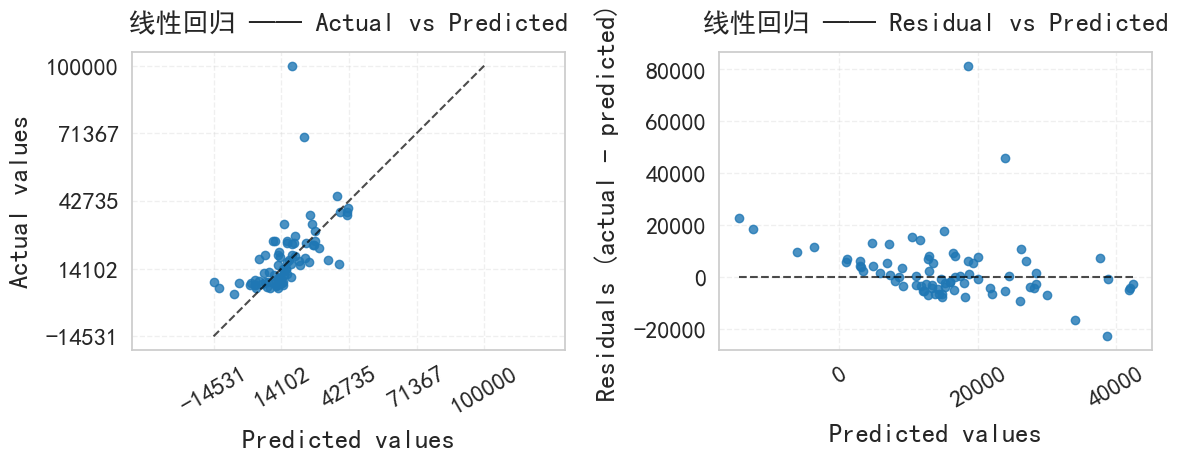


----------------------------------
决策树（CART）
----------------------------------
决策树（CART） —— 最优参数： model__max_depth=10, model__min_samples_leaf=4
决策树（CART） —— 最优RMSE（CV）：10611.51
决策树（CART） —— MAE 5443.6 | RMSE 11675.9 | R² 0.363


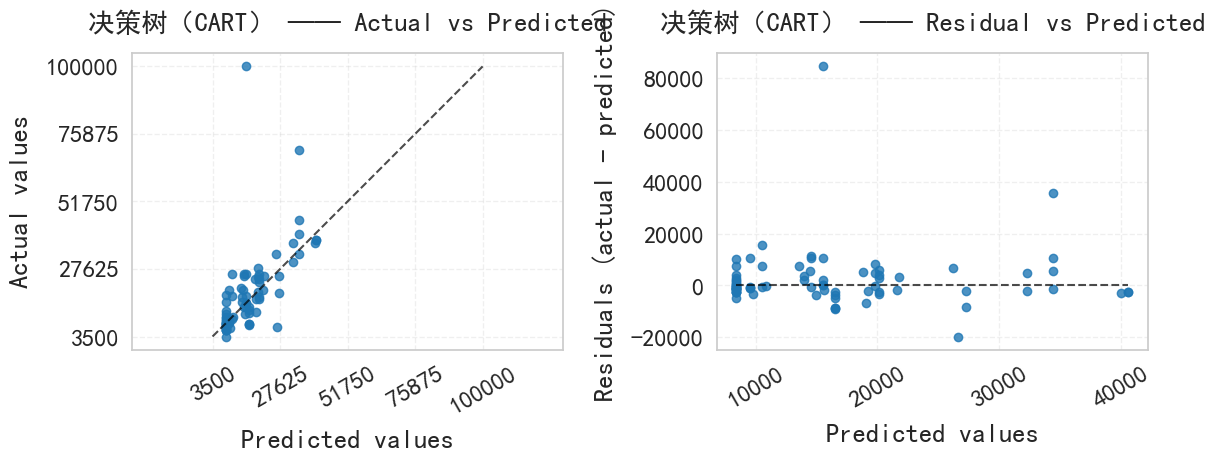


----------------------------------
随机森林（RF）
----------------------------------
随机森林（RF） —— 最优参数： model__max_depth=15, model__min_samples_leaf=4, model__n_estimators=200
随机森林（RF） —— 最优RMSE（CV）：9671.25
随机森林（RF） —— MAE 5251.8 | RMSE 11368.9 | R² 0.396


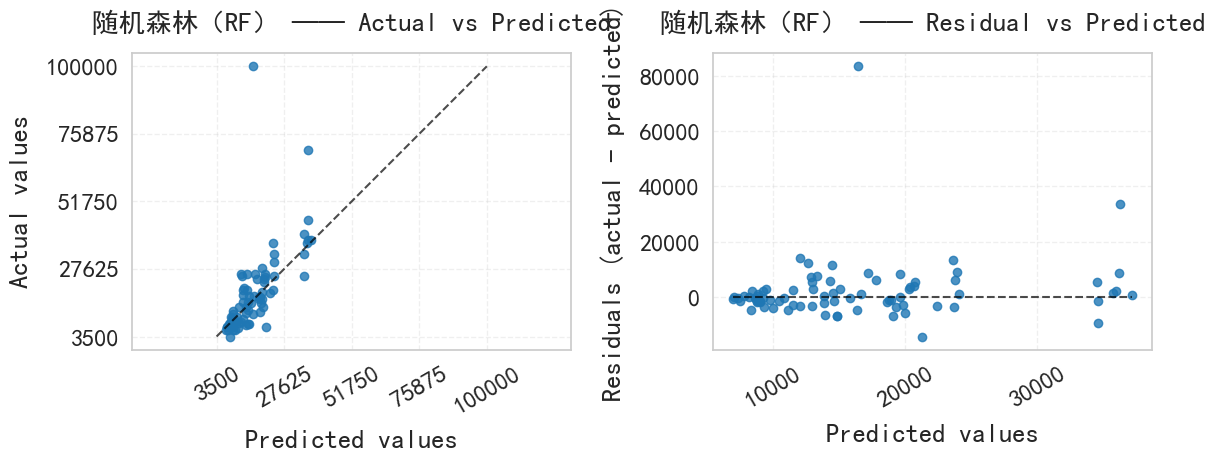


----------------------------------
LightGBM
----------------------------------
LightGBM —— 最优参数： model__learning_rate=0.05, model__max_depth=3, model__min_data_in_leaf=10, model__n_estimators=300, model__num_leaves=15
LightGBM —— 最优RMSE（CV）：10170.27
LightGBM —— MAE 5404.9 | RMSE 11528.4 | R² 0.379


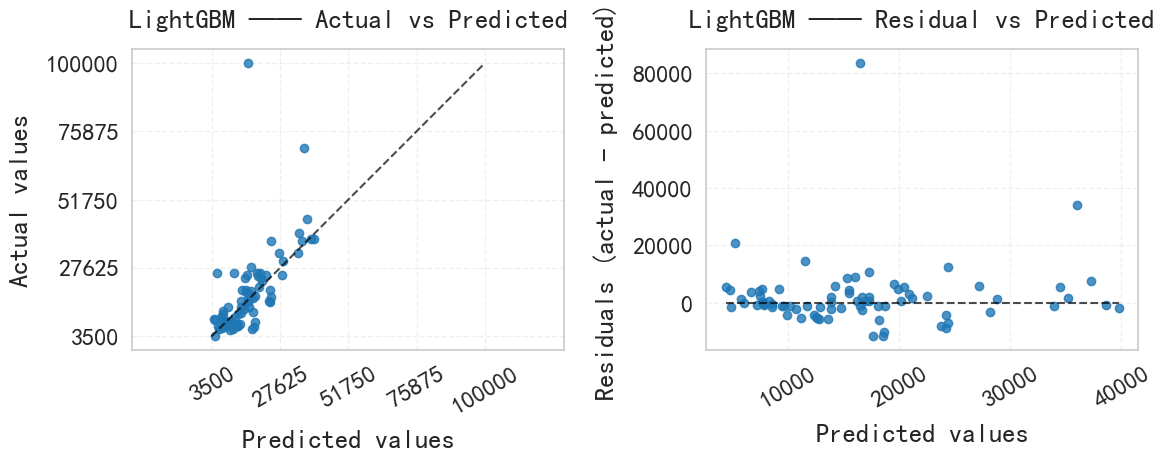


----------------------------------
回归模型性能对比表
----------------------------------
                   MAE          RMSE        R2
线性回归       7436.215088  13026.879729  0.206662
决策树（CART）  5443.611977  11675.945897  0.362674
随机森林（RF）   5251.824702  11368.867654  0.395757
LightGBM   5404.890849  11528.370614  0.378683

----------------------------------
最优模型：随机森林（RF）（R² = 0.396）
----------------------------------


In [143]:
# =========================
# 回归：用离散特征预测房价
# =========================
hr("回归：用离散特征预测房价")

# 特征选择
df_reg = df[['type', 'avg_price', 'status', 'district', 'neighborhood', 'tag_list', 'room_list']].copy()

# 将标签列和户型列拆分为独热编码
mlb = MultiLabelBinarizer()
tag_encoded = pd.DataFrame(mlb.fit_transform(df_reg['tag_list']), columns=[f"tag_{t}" for t in mlb.classes_],
                           index=df_reg.index)
room_encoded = pd.DataFrame(mlb.fit_transform(df_reg['room_list']), columns=[f"room_{r}" for r in mlb.classes_],
                            index=df_reg.index)

# 拼接进DataFrame
X_reg = pd.concat([df_reg[['type', 'status', 'district', 'neighborhood']], tag_encoded, room_encoded], axis=1)
y_reg = df_reg['avg_price']

# 类别列编码
categorical_reg = ['type', 'status', 'district', 'neighborhood']
pre_reg = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_reg)
], remainder='passthrough')

# 数据集划分
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg_results = {}


# 回归评估函数
def eval_reg(model, name, param_grid=None):
    subhr(name)

    if param_grid is not None:
        pipe = Pipeline([
            ("preprocess", pre_reg),
            ("model", model)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        grid.fit(Xr_train, yr_train)
        best_model = grid.best_estimator_

        print(f"{name} —— 最优参数：", ", ".join(f"{k}={v}" for k, v in grid.best_params_.items()))
        best_rmse = np.sqrt(-grid.best_score_)
        print(f"{name} —— 最优RMSE（CV）：{best_rmse:.2f}")

    else:
        best_model = Pipeline([
            ("preprocess", pre_reg),
            ("model", model)
        ])
        best_model.fit(Xr_train, yr_train)

    # 预测
    y_pred = best_model.predict(Xr_test)
    mae = mean_absolute_error(yr_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yr_test, y_pred))
    r2 = r2_score(yr_test, y_pred)

    # 存储结果
    reg_results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"{name} —— MAE {mae:.1f} | RMSE {rmse:.1f} | R² {r2:.3f}")

    # 绘制回归误差图
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 真实值 vs 预测值
    PredictionErrorDisplay.from_estimator(
        best_model,
        Xr_test,
        yr_test,
        kind="actual_vs_predicted",
        ax=axes[0]
    )
    axes[0].set_title(f"{name} —— Actual vs Predicted")

    # 残差 vs 预测值
    PredictionErrorDisplay.from_estimator(
        best_model,
        Xr_test,
        yr_test,
        kind="residual_vs_predicted",
        ax=axes[1]
    )
    axes[1].set_title(f"{name} —— Residual vs Predicted")

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=30)
    plt.tight_layout()
    plt.show()

    return best_model


param_lr = None
param_dt = {
    "model__max_depth": [5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4]
}
param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20],
    "model__min_samples_leaf": [1, 2, 4]
}
param_lgbm = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__num_leaves": [15, 31, 50],
    "model__min_data_in_leaf": [10, 20, 30]
}

eval_reg(LinearRegression(), "线性回归", param_lr)
eval_reg(DecisionTreeRegressor(), "决策树（CART）", param_dt)
eval_reg(RandomForestRegressor(), "随机森林（RF）", param_rf)
eval_reg(LGBMRegressor(verbose=-1), "LightGBM", param_lgbm)

performance_reg_df = pd.DataFrame(reg_results).T
subhr("回归模型性能对比表")
print(performance_reg_df)

best_model_name = performance_reg_df["R2"].idxmax()
best_r2 = performance_reg_df["R2"].max()
subhr(f"最优模型：{best_model_name}（R² = {best_r2:.3f}）")